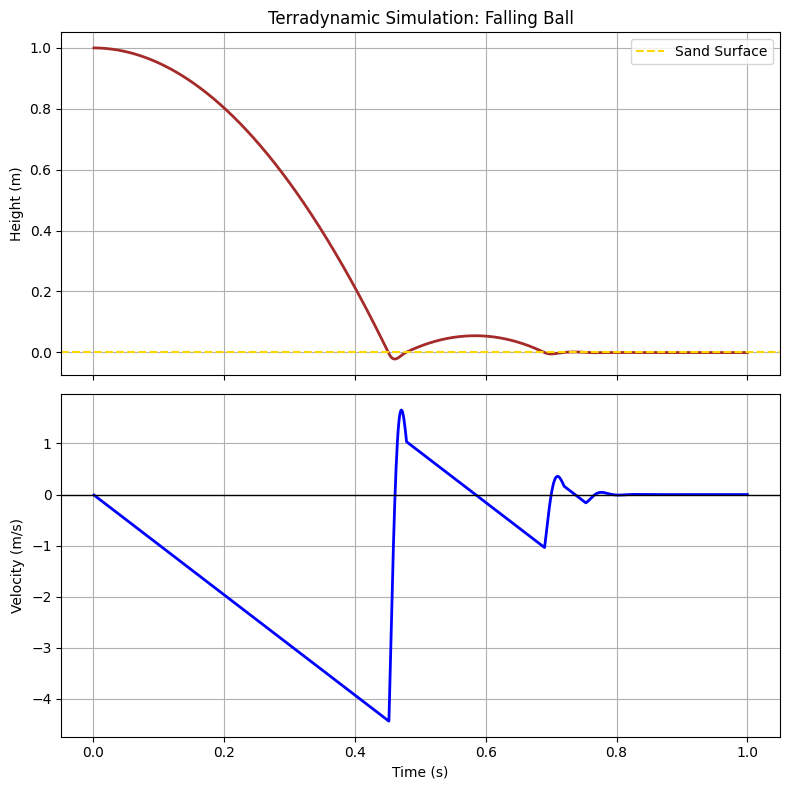

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# simple falling ball
m = 0.5          
g = 9.81         
alpha = 8000     
beta = 50        
dt = 0.001       
t_end = 1.0      

# states
z = 1.0          # Height (m)
v = 0.0          # Velocity (m/s)
t = 0.0

# Data collected
z_list, v_list, t_list = [], [], []

# sim
while t < t_end:
    f_gravity = -m * g
    
    if z < 0:
        depth = abs(z)
        # RFT Force + Damping (to make it stop moving eventually)
        f_resistive = (alpha * depth) - (beta * v)
    else:
        f_resistive = 0
        
    total_force = f_gravity + f_resistive
    
    # Physics equations
    a = total_force / m
    v += a * dt
    z += v * dt
    t += dt
    
    z_list.append(z)
    v_list.append(v)
    t_list.append(t)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Height Plot
ax1.plot(t_list, z_list, color='brown', lw=2)
ax1.axhline(0, color='gold', linestyle='--', label='Sand Surface')
ax1.set_ylabel('Height (m)')
ax1.set_title('Terradynamic Simulation: Falling Ball')
ax1.grid(True)
ax1.legend()

# Velocity Plot
ax2.plot(t_list, v_list, color='blue', lw=2)
ax2.axhline(0, color='black', lw=1)
ax2.set_ylabel('Velocity (m/s)')
ax2.set_xlabel('Time (s)')
ax2.grid(True)

plt.tight_layout()
plt.show()


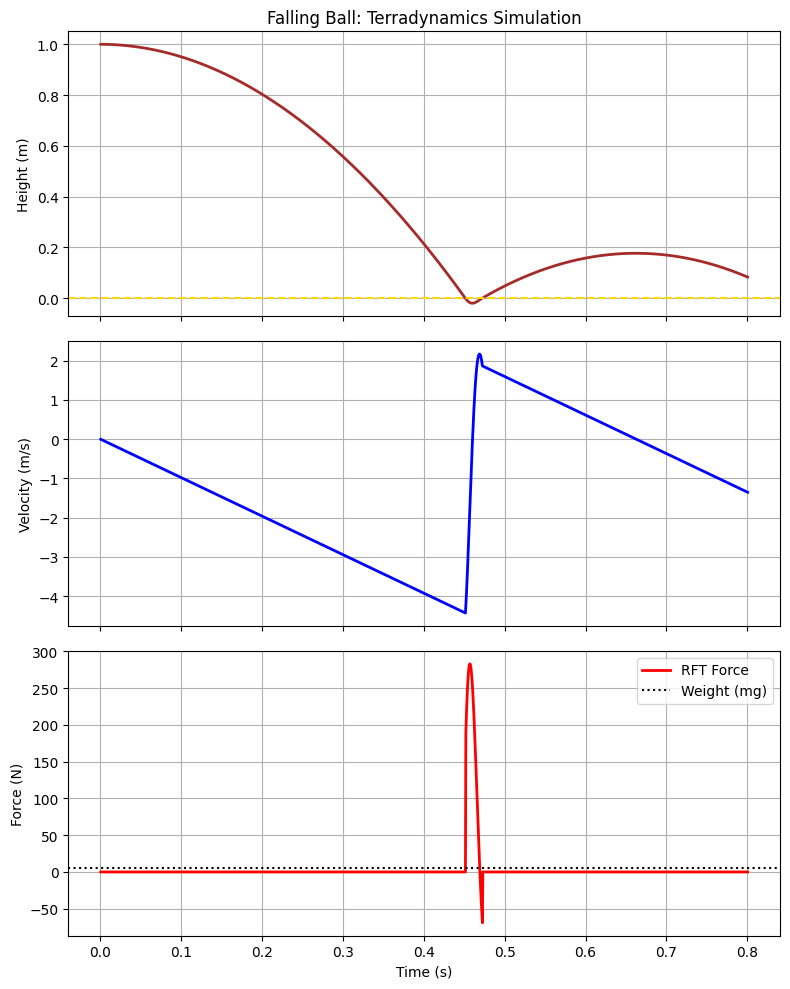

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m = 0.5          # Mass (kg)
g = 9.81         # Gravity (m/s^2)
alpha = 12000    # RFT coefficient (Stiffness of sand)
beta = 40        # Damping (Energy dissipation)
dt = 0.0005      # Smaller time step for smoother force curves
t_end = 0.8      

# Initial State
z, v, t = 1.0, 0.0, 0.0

# Data storage
z_list, v_list, f_rft_list, t_list = [], [], [], []

while t < t_end:
    f_gravity = -m * g
    
    # APPLYING RESISTIVE FORCE THEORY (RFT)
    if z < 0:
        depth = abs(z)
        # RFT says Force is proportional to depth
        f_rft = (alpha * depth) - (beta * v) 
    else:
        f_rft = 0
        
    total_force = f_gravity + f_rft
    
    # Physics Update
    a = total_force / m
    v += a * dt
    z += v * dt
    t += dt
    
    # Save data
    z_list.append(z)
    v_list.append(v)
    f_rft_list.append(f_rft) # Track the RFT force specifically
    t_list.append(t)

# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# 1. Height
ax1.plot(t_list, z_list, color='brown', lw=2)
ax1.axhline(0, color='gold', linestyle='--', label='Sand Surface')
ax1.set_ylabel('Height (m)')
ax1.set_title('Falling Ball: Terradynamics Simulation')
ax1.grid(True)

# 2. Velocity
ax2.plot(t_list, v_list, color='blue', lw=2)
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(True)

# 3. RFT Force (The Ground Reaction)
ax3.plot(t_list, f_rft_list, color='red', lw=2, label='RFT Force')
ax3.axhline(m*g, color='black', linestyle=':', label='Weight (mg)')
ax3.set_ylabel('Force (N)')
ax3.set_xlabel('Time (s)')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()


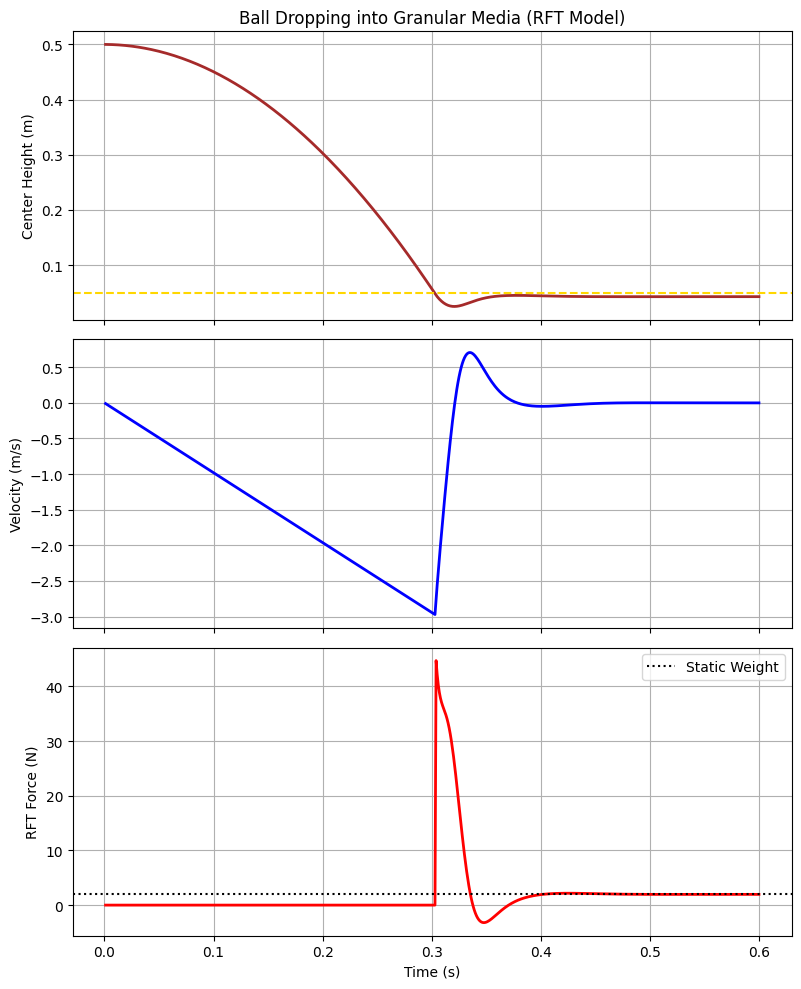

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Parameters
m = 0.2          # Mass of the ball (kg)
R = 0.05         # Radius of the ball (5cm)
g = 9.81         
dt = 0.001       
t_end = 0.6

# RFT Coefficients for "Glass Beads" (from Chen Li et al. 2013)
# For vertical intrusion (gamma = -pi/2), the average alpha_z is high.
zeta = 1.2e5     # Scaling factor for the medium (N/m^3)

# Initial State
z = 0.5          # Start height (m)
v = 0.0          # Initial velocity
t = 0.0

# Data storage
z_hist, v_hist, f_hist, t_hist = [], [], [], []

# 2. Simulation Loop
while t < t_end:
    f_gravity = -m * g
    
    # APPLYING RFT FOR A SPHERE
    if z - R <= 0:
        # Calculate how much of the ball is submerged
        h = abs(min(0, z - R)) 
        
        # Simplified RFT Integral for a sphere intruding vertically:
        # Force is proportional to the submerged volume's depth profile
        # Here we use the depth of the center-point for simplicity
        depth_eff = abs(z - R)
        
        # Area of contact increases as it sinks
        area_contact = 2 * np.pi * R * h  
        
        # RFT Force: alpha * depth * Area
        f_rft = zeta * depth_eff * area_contact
        
        # Add a small damping term for sand friction (beta)
        f_rft -= 15 * v 
    else:
        f_rft = 0
        
    total_force = f_gravity + f_rft
    
    # Update Physics
    a = total_force / m
    v += a * dt
    z += v * dt
    t += dt
    
    z_hist.append(z)
    v_hist.append(v)
    f_hist.append(f_rft)
    t_hist.append(t)

# 3. Plotting Results
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

ax1.plot(t_hist, z_hist, color='brown', lw=2)
ax1.axhline(R, color='gold', ls='--', label='Surface Touch')
ax1.set_ylabel('Center Height (m)')
ax1.set_title('Ball Dropping into Granular Media (RFT Model)')
ax1.grid(True)

ax2.plot(t_hist, v_hist, color='blue', lw=2)
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(True)

ax3.plot(t_hist, f_hist, color='red', lw=2)
ax3.axhline(m*g, color='black', ls=':', label='Static Weight')
ax3.set_ylabel('RFT Force (N)')
ax3.set_xlabel('Time (s)')
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()


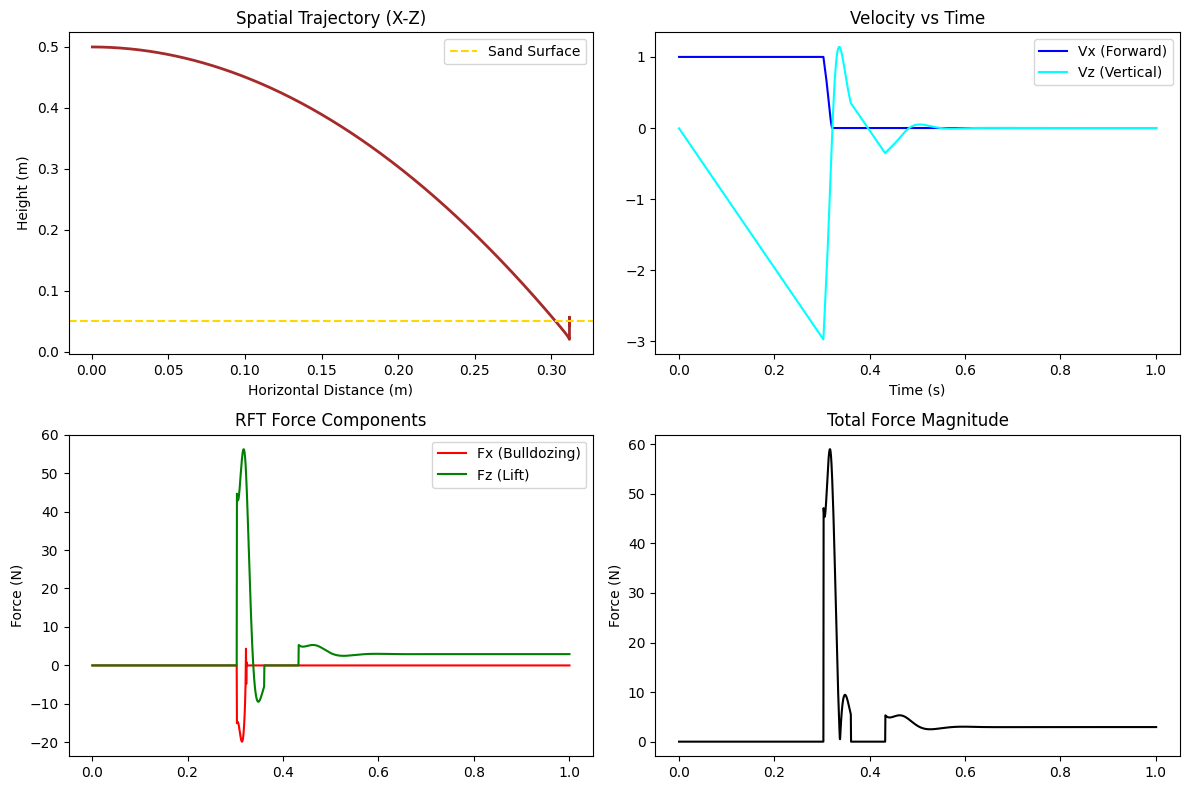

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Physics Parameters ---
m = 0.3          # Mass (kg)
R = 0.05         # Radius (m)
g = 9.81         
dt = 0.0005      # Small time step for stability
t_end = 1.0

# RFT Coefficients (Based on Chen Li et al. 2013)
zeta = 1.8e5     # Media scaling (N/m^3)
beta = 15.0      # Damping (Internal grain friction)

# Initial State: 1 m/s forward push + dropping from 0.5m
x, z = 0.0, 0.5  
vx, vz = 1.0, 0.0 
t = 0.0

# Data storage
x_h, z_h, vx_h, vz_h, fx_h, fz_h, t_h = [], [], [], [], [], [], []

# --- 2. Simulation Loop ---
while t < t_end:
    # Gravity always pulls down
    f_grav_z = -m * g
    
    f_rft_x = 0.0
    f_rft_z = 0.0
    
    # Check for Ground Contact (RFT only active when submerged)
    if z - R < 0:
        depth = abs(z - R)
        area = 2 * np.pi * R * depth # Simplified contact area
        
        # Calculate Angle of Intrusion (gamma)
        gamma = np.arctan2(vz, vx)
        
        # --- VERTICAL FORCE (Lift) ---
        alpha_z = zeta * np.abs(np.sin(gamma))
        f_rft_z = (alpha_z * depth * area) - (beta * vz)
        
        # --- HORIZONTAL FORCE (Bulldozing) ---
        # CRITICAL FIX: Force only exists if the ball is moving (Inelastic)
        if abs(vx) > 0.001:
            alpha_x = zeta * 1.5 * np.abs(np.cos(gamma)) 
            # Force magnitude
            f_mag_x = (alpha_x * depth * area) + (beta * abs(vx))
            # Direction: Force is ALWAYS opposite to velocity (Drag)
            f_rft_x = -np.sign(vx) * f_mag_x
        else:
            vx = 0  # Come to a complete stop
            f_rft_x = 0
            
    # --- 3. Physics Update (Newton-Euler) ---
    ax = f_rft_x / m
    az = (f_grav_z + f_rft_z) / m
    
    # Update Velocities
    vx += ax * dt
    vz += az * dt
    
    # Update Positions
    x += vx * dt
    z += vz * dt
    t += dt

    # Store for plotting
    for var, list_h in zip([x, z, vx, vz, f_rft_x, f_rft_z, t], 
                           [x_h, z_h, vx_h, vz_h, fx_h, fz_h, t_h]):
        list_h.append(var)

# --- 4. Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# A. Trajectory: Shows the "Plow" path into the sand
axes[0,0].plot(x_h, z_h, color='brown', lw=2)
axes[0,0].axhline(R, color='gold', ls='--', label='Sand Surface')
axes[0,0].set_title('Spatial Trajectory (X-Z)')
axes[0,0].set_xlabel('Horizontal Distance (m)')
axes[0,0].set_ylabel('Height (m)')
axes[0,0].legend()

# B. Velocities: Vx should hit zero and STAY zero (No bouncing)
axes[0,1].plot(t_h, vx_h, label='Vx (Forward)', color='blue')
axes[0,1].plot(t_h, vz_h, label='Vz (Vertical)', color='cyan')
axes[0,1].set_title('Velocity vs Time')
axes[0,1].set_xlabel('Time (s)')
axes[0,1].legend()

# C. Separated Forces: Fx is the Bulldozing Drag
axes[1,0].plot(t_h, fx_h, label='Fx (Bulldozing)', color='red')
axes[1,0].plot(t_h, fz_h, label='Fz (Lift)', color='green')
axes[1,0].set_title('RFT Force Components')
axes[1,0].set_ylabel('Force (N)')
axes[1,0].legend()

# D. Magnitude: Total Ground Reaction
axes[1,1].plot(t_h, np.sqrt(np.array(fx_h)**2 + np.array(fz_h)**2), color='black')
axes[1,1].set_title('Total Force Magnitude')
axes[1,1].set_ylabel('Force (N)')

plt.tight_layout()
plt.show()


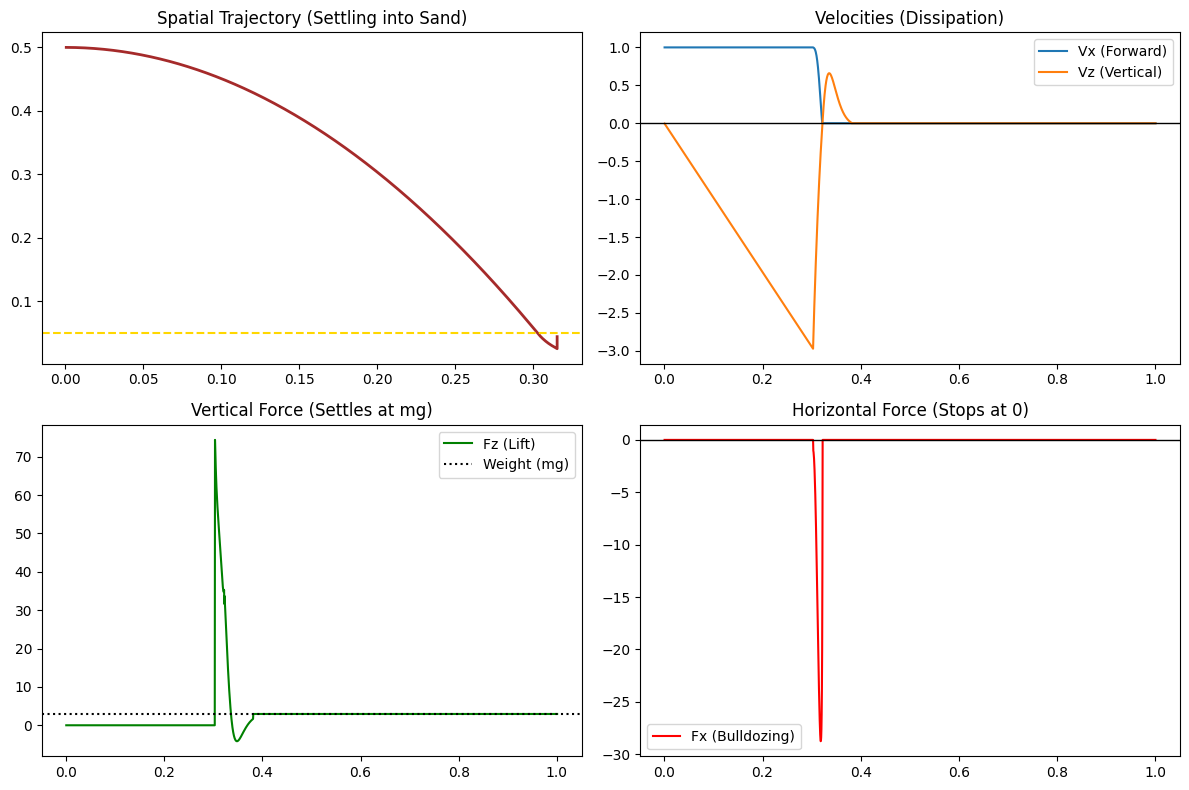

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Physics Parameters ---
m = 0.3          # Mass (kg)
R = 0.05         # Radius (m)
g = 9.81         
dt = 0.0005      
t_end = 1.0

# RFT Coefficients (Accurate for dry sand/glass beads)
zeta = 1.8e5     
beta_z = 25.0    # High vertical damping (Dissipation)
beta_x = 1.0    # High horizontal damping (Bulldozing friction)

# Initial State
x, z = 0.0, 0.5  
vx, vz = 1.0, 0.0 
t = 0.0

# Data storage
x_h, z_h, vx_h, vz_h, fx_h, fz_h, t_h = [], [], [], [], [], [], []

# --- 2. Simulation Loop ---
while t < t_end:
    f_grav_z = -m * g
    f_rft_x = 0.0
    f_rft_z = 0.0
    
    # Check for Ground Contact
    if z - R < 0:
        depth = abs(z - R)
        area = 2 * np.pi * R * depth
        gamma = np.arctan2(vz, vx)
        
        # --- VERTICAL FORCE (Lift + Dissipation) ---
        # The force is ONLY active if it's moving or needs to support weight
        alpha_z = zeta * np.abs(np.sin(gamma))
        f_lift = (alpha_z * depth * area)
        f_damping_z = -beta_z * vz
        f_rft_z = f_lift + f_damping_z
        
        # --- HORIZONTAL FORCE (Bulldozing) ---
        # If velocity is near zero, horizontal force stops (No spring back)
        if abs(vx) > 0.005:
            alpha_x = zeta * 1.5 * np.abs(np.cos(gamma)) 
            f_rft_x = -np.sign(vx) * (alpha_x * depth * area + beta_x * abs(vx))
        else:
            vx = 0
            f_rft_x = 0

    # --- 3. Physics Update ---
    ax = f_rft_x / m
    az = (f_grav_z + f_rft_z) / m
    
    # Update Velocities
    vx += ax * dt
    vz += az * dt
    
    # STATIC EQUILIBRIUM CHECK:
    # If the ball is moving very slowly and buried, stop it.
    if abs(vz) < 0.005 and (z - R) < 0:
        vz = 0
        # In static equilibrium, the ground force MUST equal weight
        f_rft_z = -f_grav_z 

    # Update Positions
    x += vx * dt
    z += vz * dt
    t += dt

    # Store for plotting
    for var, list_h in zip([x, z, vx, vz, f_rft_x, f_rft_z, t], 
                           [x_h, z_h, vx_h, vz_h, fx_h, fz_h, t_h]):
        list_h.append(var)

# --- 4. Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Trajectory
axes[0,0].plot(x_h, z_h, color='brown', lw=2)
axes[0,0].axhline(R, color='gold', ls='--', label='Surface')
axes[0,0].set_title('Spatial Trajectory (Settling into Sand)')

# Velocities (Should hit 0 and stay 0)
axes[0,1].plot(t_h, vx_h, label='Vx (Forward)')
axes[0,1].plot(t_h, vz_h, label='Vz (Vertical)')
axes[0,1].axhline(0, color='black', lw=1)
axes[0,1].set_title('Velocities (Dissipation)')
axes[0,1].legend()

# Forces (Fz should settle at mg)
axes[1,0].plot(t_h, fz_h, label='Fz (Lift)', color='green')
axes[1,0].axhline(m*g, color='black', ls=':', label='Weight (mg)')
axes[1,0].set_title('Vertical Force (Settles at mg)')
axes[1,0].legend()

# Horizontal Force (Should hit 0)
axes[1,1].plot(t_h, fx_h, label='Fx (Bulldozing)', color='red')
axes[1,1].axhline(0, color='black', lw=1)
axes[1,1].set_title('Horizontal Force (Stops at 0)')
axes[1,1].legend()

plt.tight_layout()
plt.show()
